In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("modified_data_with_recent_form.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

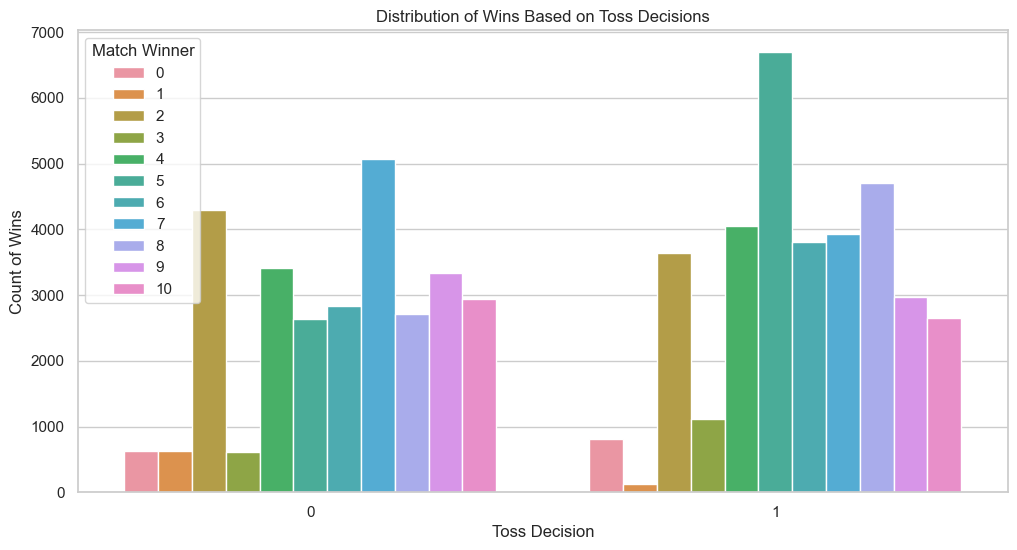

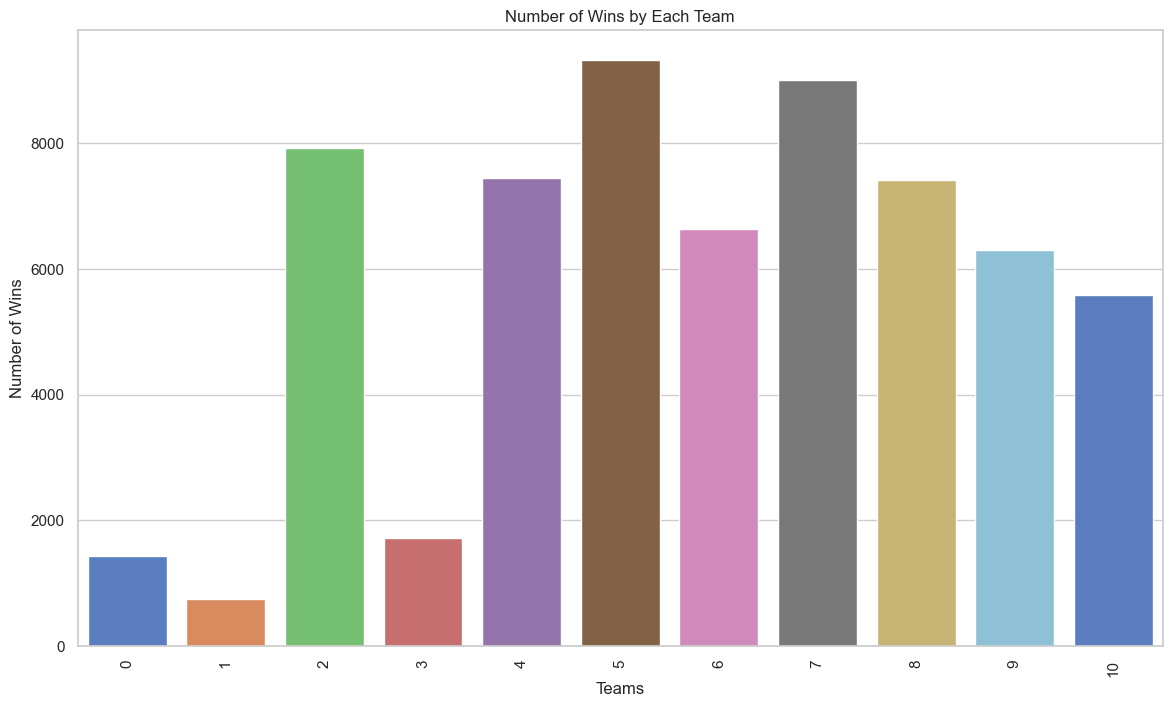

In [48]:
# Set the style for the plots
sns.set(style="whitegrid")

# Distribution of wins based on toss decisions
plt.figure(figsize=(12, 6))
sns.countplot(x='toss_decision', hue='match_winner', data=data)
plt.title('Distribution of Wins Based on Toss Decisions')
plt.xlabel('Toss Decision')
plt.ylabel('Count of Wins')
plt.legend(title='Match Winner')
plt.show()

# Distribution of wins based on teams
plt.figure(figsize=(14, 8))
team_win_data = data['match_winner'].value_counts()
sns.barplot(x=team_win_data.index, y=team_win_data.values, palette="muted")
plt.title('Number of Wins by Each Team')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=90)
plt.show()



In [5]:
from sklearn.preprocessing import LabelEncoder
categorical_columns = data.select_dtypes(include=['object']).columns

label_encoder = LabelEncoder()

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

data.head()

,match_id,team_1,team_2,batting_team,bowling_team,ball,batsman,bowler,runs,player_dismissed,...,max_tempC,min_tempC,sun_hour,match_outcome,toss_effective,team_1_win_rate_bat_first,team_2_win_rate_bat_first,team_1_win,team_2_win,recent_form
0,181,5,1,1,5,19.6,315,26,0,5,...,26.18865,18.696183,10.724949,0,0,0.094793,0.020435,0,1,0
1,181,5,1,1,5,4.6,139,108,1,3,...,26.18865,18.696183,10.724949,0,0,0.094793,0.020435,0,1,0
2,181,5,1,1,5,5.1,139,207,0,4,...,26.18865,18.696183,10.724949,0,0,0.094793,0.020435,0,1,1
3,181,5,1,1,5,5.2,480,207,1,4,...,26.18865,18.696183,10.724949,0,0,0.094793,0.020435,0,1,1
4,181,5,1,1,5,5.3,451,207,1,4,...,26.18865,18.696183,10.724949,0,0,0.094793,0.020435,0,1,1


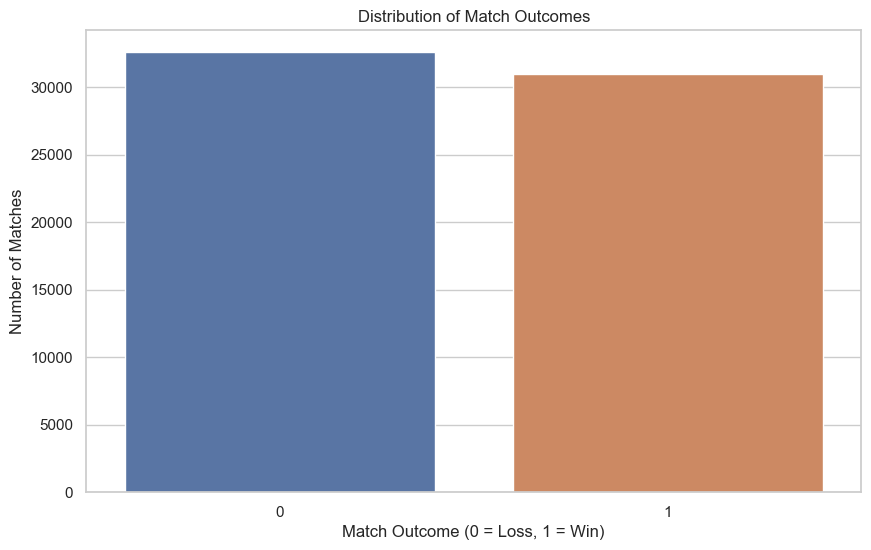

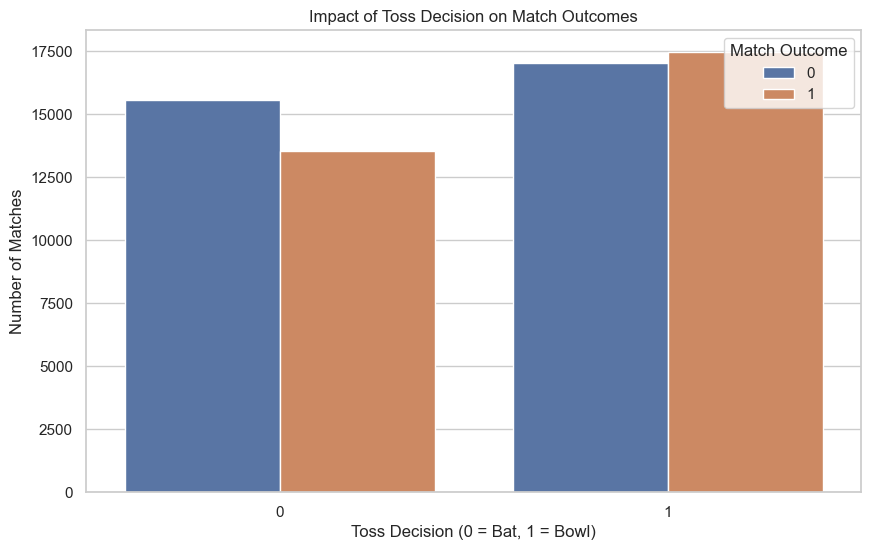

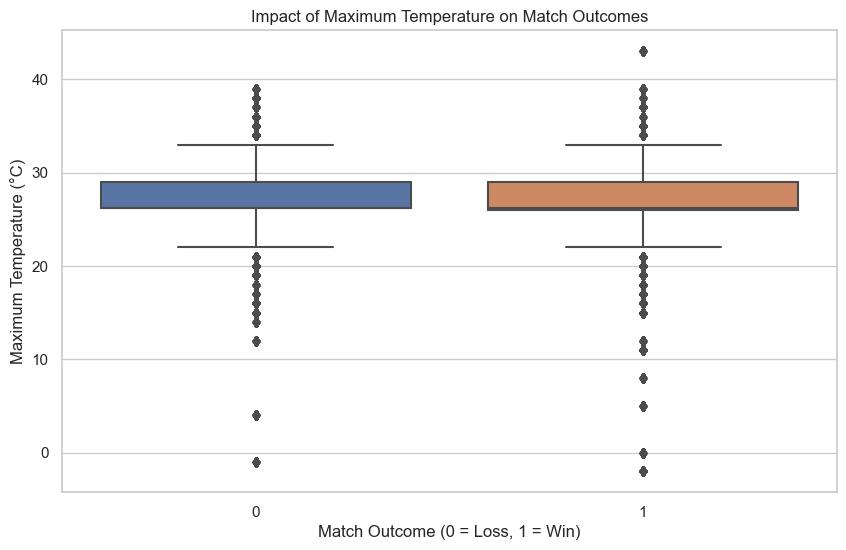

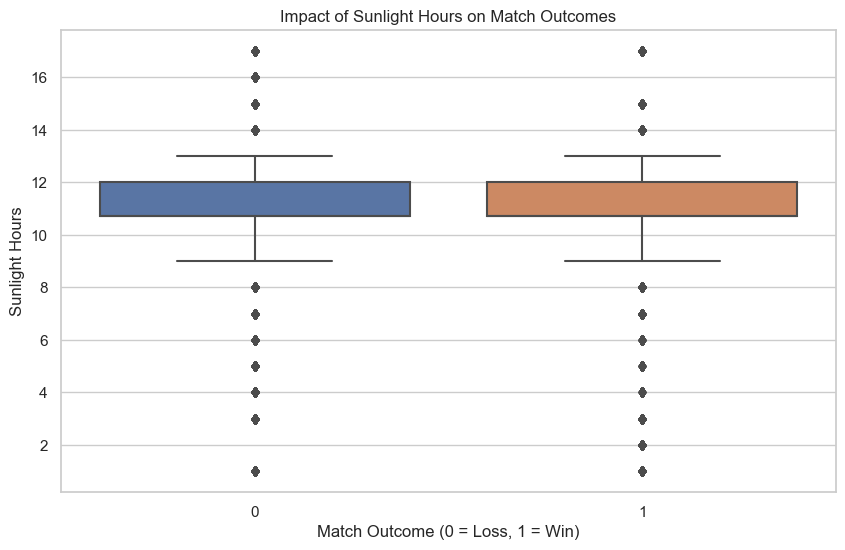

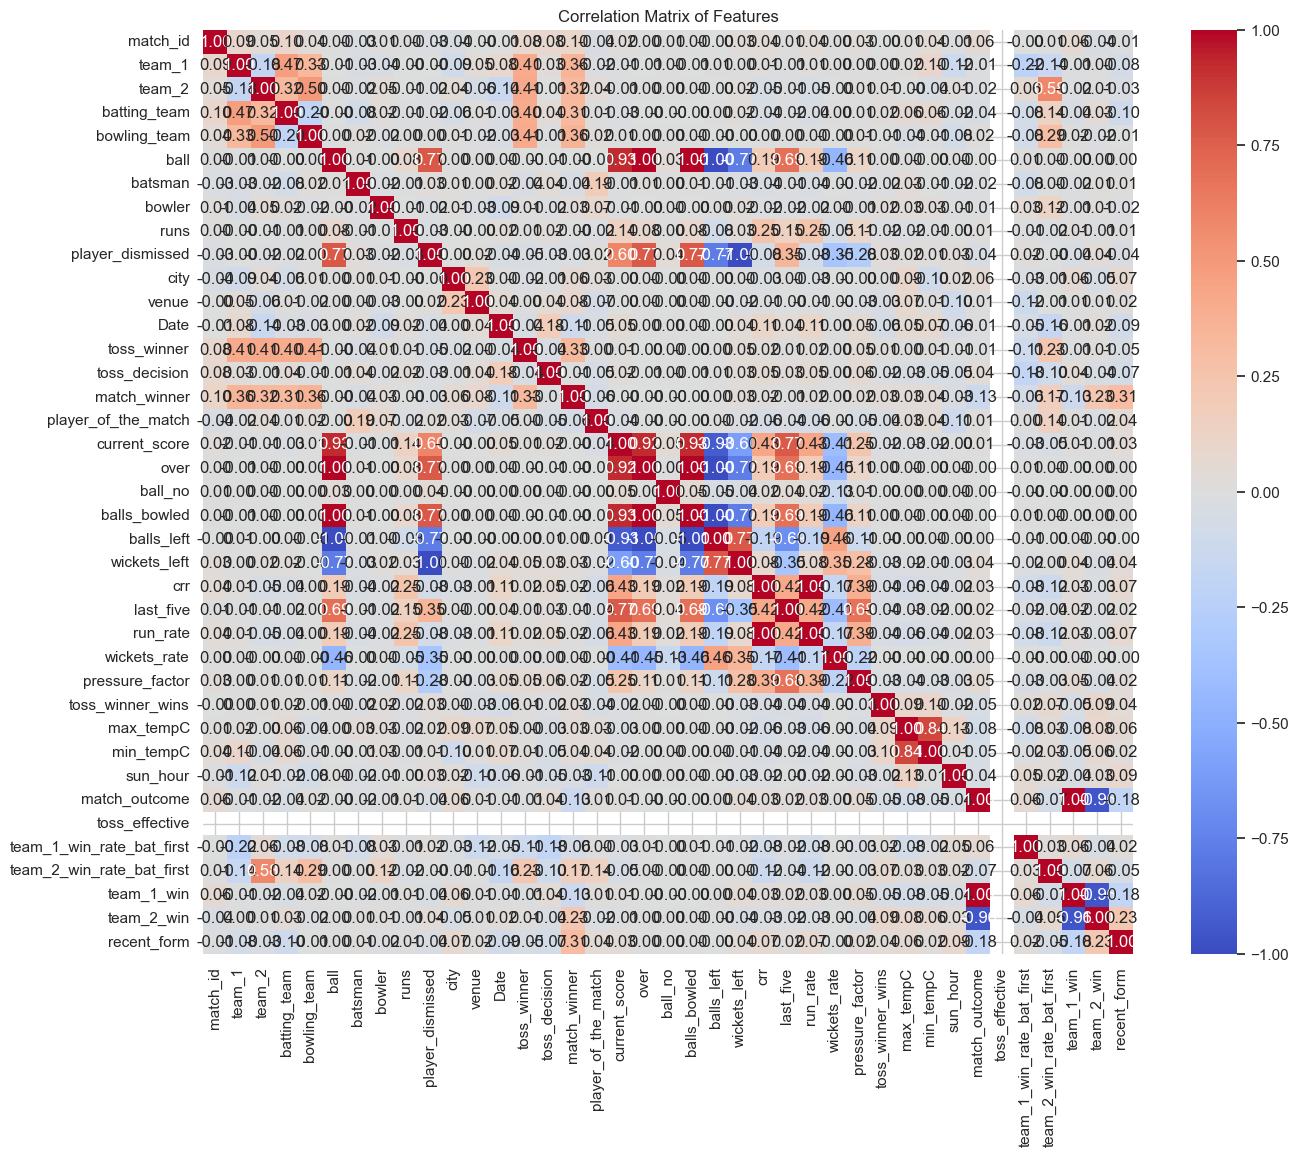

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set(style="whitegrid")

# 1. Distribution of Wins and Losses
plt.figure(figsize=(10, 6))
sns.countplot(x='match_outcome', data=data)
plt.title('Distribution of Match Outcomes')
plt.xlabel('Match Outcome (0 = Loss, 1 = Win)')
plt.ylabel('Number of Matches')
plt.show()

# 2. Toss Decision Impact
plt.figure(figsize=(10, 6))
sns.countplot(x='toss_decision', hue='match_outcome', data=data)
plt.title('Impact of Toss Decision on Match Outcomes')
plt.xlabel('Toss Decision (0 = Bat, 1 = Bowl)')
plt.ylabel('Number of Matches')
plt.legend(title='Match Outcome', loc='upper right')
plt.show()

# 3. Weather Conditions Impact
plt.figure(figsize=(10, 6))
sns.boxplot(x='match_outcome', y='max_tempC', data=data)
plt.title('Impact of Maximum Temperature on Match Outcomes')
plt.xlabel('Match Outcome (0 = Loss, 1 = Win)')
plt.ylabel('Maximum Temperature (°C)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='match_outcome', y='sun_hour', data=data)
plt.title('Impact of Sunlight Hours on Match Outcomes')
plt.xlabel('Match Outcome (0 = Loss, 1 = Win)')
plt.ylabel('Sunlight Hours')
plt.show()

# 4. Correlation Matrix
plt.figure(figsize=(15, 12))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
features = data.drop(columns=['match_outcome', 'team_1_win', 'team_2_win'])
target = data['match_outcome']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

In [12]:
print(accuracy)
print(conf_matrix)
print(class_report)

1.0
[[9853    0]
 [   0 9218]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9853
           1       1.00      1.00      1.00      9218

    accuracy                           1.00     19071
   macro avg       1.00      1.00      1.00     19071
weighted avg       1.00      1.00      1.00     19071



In [13]:
importances = rf_model.feature_importances_
feature_names = features.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})


In [14]:
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

In [15]:
top_features = feature_importance_df.head(15)
top_features

,feature,importance
15,match_winner,0.161177
1,team_1,0.123714
2,team_2,0.116039
34,team_2_win_rate_bat_first,0.084333
33,team_1_win_rate_bat_first,0.064091
16,player_of_the_match,0.047701
12,Date,0.046334
10,city,0.037938
0,match_id,0.036876
35,recent_form,0.035878


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [17]:
X_train_top = X_train[top_features['feature']]
X_test_top = X_test[top_features['feature']]

In [18]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_top, y_train)
y_pred_lr = lr_model.predict(X_test_top)

/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_top, y_train)
y_pred_gb = gb_model.predict(X_test_top)

In [20]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
accuracy_rf = accuracy_score(y_test, y_pred)

In [21]:
model_performance = {
    "Model": ["Logistic Regression", "Gradient Boosting", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_gb, accuracy_rf]
}

In [22]:
model_performance_df = pd.DataFrame(model_performance)
model_performance_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,1.000000
1,Gradient Boosting,0.998951
0,Logistic Regression,0.618636


Analysis two

In [23]:
cleaned_df=pd.read_csv("cleaned_df_with_temp.csv")

In [24]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test, force_dense=False):
    if force_dense:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('to_dense', FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)),
            ('model', model)
        ])
    else:
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    print(f"Model: {model.__class__.__name__}")
    print("Overall Accuracy:", accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))
    print("-" * 80)


In [25]:

cleaned_df.rename(columns={'Team 1': 'team_1', 'Team 2': 'team_2'}, inplace=True)

# Check the new column names to confirm they have been renamed
print(cleaned_df.columns)

Index(['match_id', 'team_1', 'team_2', 'batting_team', 'bowling_team', 'ball',
       'batsman', 'bowler', 'runs', 'player_dismissed', 'city', 'venue',
       'Date', 'toss_winner', 'toss_decision', 'match_winner',
       'player_of_the_match', 'current_score', 'over', 'ball_no',
       'balls_bowled', 'balls_left', 'wickets_left', 'crr', 'last_five',
       'run_rate', 'wickets_rate', 'pressure_factor', 'toss_winner_wins',
       'max_tempC', 'min_tempC', 'sun_hour'],
      dtype='object')


In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Convert match_winner to string type to ensure consistency
cleaned_df['match_winner'] = cleaned_df['match_winner'].astype(str)

categorical_features = ['venue', 'team_1','team_2','batting_team', 'bowling_team', 'toss_decision', 'toss_winner']
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour']

# Column Transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])



X = cleaned_df.drop(['match_id', 'match_winner'], axis=1)
y = cleaned_df['match_winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models and whether they need dense data
models = [
    (SVC(kernel='rbf', random_state=42), False),
    (DecisionTreeClassifier(random_state=42), False),
    (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
    (GaussianNB(), True)
]

# Train and evaluate each model
for model, needs_dense in models:
    train_and_evaluate(model, X_train, X_test, y_train, y_test, force_dense=needs_dense)


Model: SVC
Overall Accuracy: 0.9664936290703162
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       270
 Afghanistan       1.00      1.00      1.00       156
   Australia       0.98      0.97      0.97      1574
  Bangladesh       0.92      0.91      0.92       340
     England       1.00      0.95      0.97      1475
       India       0.99      0.98      0.99      1856
 New Zealand       0.92      1.00      0.96      1302
    Pakistan       0.97      0.97      0.97      1820
South Africa       0.98      0.97      0.97      1476
   Sri Lanka       0.94      0.94      0.94      1289
 West Indies       0.96      0.96      0.96      1156

    accuracy                           0.97     12714
   macro avg       0.96      0.97      0.96     12714
weighted avg       0.97      0.97      0.97     12714

--------------------------------------------------------------------------------
Model: DecisionTreeClassifier
Overall Accuracy: 0.97435897

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Define the categorical and numerical features
categorical_features = ['venue', 'team_1', 'team_2', 'batting_team', 'bowling_team', 'toss_decision', 'toss_winner']
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
])


pipeline.fit(X_train, y_train)



X = cleaned_df.drop(['match_id', 'match_winner'], axis=1)
y = cleaned_df['match_winner']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scores = cross_val_score(pipeline, X_train, y_train, cv=5)  
print("Cross-validation scores:", scores)
print("Average cross-validation score: {:.2f}".format(scores.mean()))


Cross-validation scores: [0.97256907 0.97306066 0.97374889 0.97404385 0.97374889]
Average cross-validation score: 0.97


In [28]:

pipeline.fit(X_train, y_train)

# Evaluate on the test set
y_pred = pipeline.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Classification report on test set:\n", classification_report(y_test, y_pred))


Accuracy on test set: 0.974044360547428
Classification report on test set:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95       270
 Afghanistan       1.00      1.00      1.00       156
   Australia       0.98      0.97      0.97      1574
  Bangladesh       0.92      1.00      0.96       340
     England       0.97      0.97      0.97      1475
       India       0.99      1.00      0.99      1856
 New Zealand       0.98      0.96      0.97      1302
    Pakistan       0.96      1.00      0.98      1820
South Africa       0.98      0.97      0.98      1476
   Sri Lanka       0.98      0.94      0.96      1289
 West Indies       0.98      0.96      0.97      1156

    accuracy                           0.97     12714
   macro avg       0.97      0.98      0.97     12714
weighted avg       0.97      0.97      0.97     12714



In [29]:
from sklearn.metrics import make_scorer, f1_score

# Using F1-score as the scoring metric
f1_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring=make_scorer(f1_score, average='weighted'))
print("Cross-validation F1-scores:", f1_scores)
print("Average F1-score: {:.2f}".format(f1_scores.mean()))


Cross-validation F1-scores: [0.97249922 0.97296179 0.97367723 0.97395363 0.97369493]
Average F1-score: 0.97


In [31]:
unseen_data=pd.read_csv("cleaned_df_with_temp_not_used.csv")

In [32]:

unseen_data.rename(columns={'Team 1': 'team_1', 'Team 2': 'team_2'}, inplace=True)

# Check the new column names to confirm they have been renamed
print(unseen_data.columns)

Index(['match_id', 'team_1', 'team_2', 'batting_team', 'bowling_team', 'ball',
       'batsman', 'bowler', 'runs', 'player_dismissed', 'city', 'venue',
       'Date', 'toss_winner', 'toss_decision', 'match_winner',
       'player_of_the_match', 'current_score', 'over', 'ball_no',
       'balls_bowled', 'balls_left', 'wickets_left', 'crr', 'last_five',
       'run_rate', 'wickets_rate', 'pressure_factor', 'max_tempC', 'min_tempC',
       'sun_hour'],
      dtype='object')


In [33]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



# Extracting features from the unseen data
X_unseen = unseen_data.drop(['match_id', 'match_winner'], axis=1)  
y_unseen = unseen_data['match_winner']  

# Predict using the trained pipeline
y_pred_unseen = pipeline.predict(X_unseen)

# Evaluate the predictions
accuracy = accuracy_score(y_unseen, y_pred_unseen)
print(f"Accuracy on unseen data: {accuracy:.2f}")
print("\nClassification Report on Unseen Data:")
print(classification_report(y_unseen, y_pred_unseen))



Accuracy on unseen data: 0.67

Classification Report on Unseen Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       127
 Afghanistan       1.00      0.50      0.67       490
   Australia       0.85      0.85      0.85       830
  Bangladesh       0.00      0.00      0.00       247
     England       0.50      0.67      0.57       374
       India       0.89      1.00      0.94       995
 New Zealand       0.51      0.33      0.40       766
    Pakistan       0.36      1.00      0.53       359
South Africa       0.64      0.78      0.70       572
   Sri Lanka       0.57      1.00      0.72       488
 West Indies       1.00      0.34      0.50       746

    accuracy                           0.67      5994
   macro avg       0.57      0.59      0.54      5994
weighted avg       0.70      0.67      0.64      5994



/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/nikhil/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [34]:
from sklearn.metrics import balanced_accuracy_score

# Predict on unseen data
y_pred_unseen = pipeline.predict(X_unseen)

# Calculate balanced accuracy
balanced_accuracy = balanced_accuracy_score(y_unseen, y_pred_unseen)
print(f"Balanced Accuracy on unseen data: {balanced_accuracy:.2f}")


Balanced Accuracy on unseen data: 0.59


In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import permutation_importance



# Define the binary outcome
cleaned_df['match_outcome'] = (cleaned_df['team_1'] == cleaned_df['match_winner']).astype(int)

# Select features, ensuring no feature leakage
features_to_use = ['venue', 'team_1', 'team_2', 'toss_winner', 'toss_decision', 'max_tempC', 'min_tempC', 'sun_hour']
X = cleaned_df[features_to_use]
y = cleaned_df['match_outcome']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing steps for numerical and categorical data
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour']
categorical_features = ['venue', 'team_1', 'team_2', 'toss_winner', 'toss_decision']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipeline setup
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Analyze feature importance
results = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importance_sorted = sorted(zip(results.importances_mean, features_to_use), reverse=True)
print("Feature Importance:\n")
for importance, name in importance_sorted:
    print(f"{name}: {importance:.4f}")


Accuracy: 0.9752241623407267
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      6560
           1       0.97      0.97      0.97      6154

    accuracy                           0.98     12714
   macro avg       0.98      0.98      0.98     12714
weighted avg       0.98      0.98      0.98     12714

Feature Importance:

team_2: 0.1118
team_1: 0.0998
venue: 0.0944
toss_winner: 0.0634
max_tempC: 0.0375
toss_decision: 0.0361
min_tempC: 0.0116
sun_hour: 0.0064


In [36]:
unseen_data['match_outcome'] = (unseen_data['team_1'] == unseen_data['match_winner']).astype(int)  # Only if outcome needs to be checked
features_to_use = ['venue', 'team_1', 'team_2', 'toss_winner', 'toss_decision', 'max_tempC', 'min_tempC', 'sun_hour']
X_unseen = unseen_data[features_to_use]

In [37]:
# Predict outcomes on the unseen data
y_unseen_pred = pipeline.predict(X_unseen)



In [38]:
# If actual outcomes are known and included in unseen_data
y_unseen_actual = unseen_data['match_outcome']

# Calculate accuracy and other metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy on unseen data:", accuracy_score(y_unseen_actual, y_unseen_pred))
print("Classification report on unseen data:\n", classification_report(y_unseen_actual, y_unseen_pred))
print("Confusion Matrix:\n", confusion_matrix(y_unseen_actual, y_unseen_pred))


Accuracy on unseen data: 0.594260927594261
Classification report on unseen data:
               precision    recall  f1-score   support

           0       0.43      0.74      0.54      1946
           1       0.81      0.52      0.63      4048

    accuracy                           0.59      5994
   macro avg       0.62      0.63      0.59      5994
weighted avg       0.69      0.59      0.61      5994

Confusion Matrix:
 [[1449  497]
 [1935 2113]]


In [39]:
# First, ensure the prediction for training and unseen datasets are stored properly:
y_train_proba = pipeline.predict_proba(X_train)[:, 1]  # Probabilities for 'team_1' winning on the training data
y_test_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilities for 'team_1' winning on the test data

# Applying a custom threshold of 0.5 (as an example, can be optimized)
threshold = 0.5
y_train_pred_custom = (y_train_proba >= threshold).astype(int)
y_test_pred_custom = (y_test_proba >= threshold).astype(int)

# Evaluate custom threshold predictions
print("Custom threshold - Accuracy on training data:", accuracy_score(y_train, y_train_pred_custom))
print("Custom threshold - Accuracy on test data:", accuracy_score(y_test, y_test_pred_custom))


Custom threshold - Accuracy on training data: 0.9772097138924393
Custom threshold - Accuracy on test data: 0.9752241623407267


In [40]:
# Create a binary target based on whether the toss decision matched the match outcome
# Assuming 'match_outcome' correctly indicates the winner
cleaned_df['toss_effective'] = (cleaned_df['toss_decision'] == cleaned_df['match_outcome']).astype(int)

# Filter to focus only on matches where the toss winner won the match
toss_win_effective_df = cleaned_df[cleaned_df['toss_winner'] == cleaned_df['match_winner']]

# Select features that might influence the decision
features = ['venue', 'team_1', 'team_2', 'toss_winner', 'max_tempC', 'min_tempC', 'sun_hour']
X = toss_win_effective_df[features]
y = toss_win_effective_df['toss_decision']  # Use toss decision directly if modeling decision strategy

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipeline
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour']
categorical_features = ['venue', 'team_1', 'team_2', 'toss_winner']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Modeling pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict the effectiveness of toss decisions on new data
y_pred = pipeline.predict(X_test)
print("Model accuracy on test set:", accuracy_score(y_test, y_pred))

Model accuracy on test set: 0.9857074032439377


In [41]:
expected_columns = ['venue', 'team_1', 'team_2', 'toss_winner', 'max_tempC', 'min_tempC', 'sun_hour']
# Prepare features from unseen data
X_unseen = unseen_data[expected_columns]

# Predict using the trained pipeline
y_unseen_pred = pipeline.predict(X_unseen)


In [42]:
# Check if actual outcomes are available and evaluate predictions
if 'toss_decision' in unseen_data.columns:
    y_unseen_actual = unseen_data['toss_decision']
    accuracy_unseen = accuracy_score(y_unseen_actual, y_unseen_pred)
    print("Accuracy on unseen data:", accuracy_unseen)
    print("Classification Report on Unseen Data:\n", classification_report(y_unseen_actual, y_unseen_pred))
else:
    print("Predictions made on unseen data, but no actual outcomes provided for accuracy assessment.")


Accuracy on unseen data: 0.4657991324657991
Classification Report on Unseen Data:
               precision    recall  f1-score   support

         bat       0.23      0.44      0.30      1565
       field       0.71      0.48      0.57      4429

    accuracy                           0.47      5994
   macro avg       0.47      0.46      0.43      5994
weighted avg       0.58      0.47      0.50      5994



In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample



# Feature engineering: Adding team win rates
# Calculate win rates for Team 1 and Team 2 when they decided to bat first and won
# Assuming 'toss_decision' can be 'bat' or 'field' and 'match_winner' indicates the winning team

# For Team 1
cleaned_df['team_1_win_rate_bat_first'] = cleaned_df.apply(
    lambda row: 1 if (row['toss_winner'] == row['team_1'] and 
                      row['toss_decision'] == 'bat' and 
                      row['match_winner'] == row['team_1']) else 0, axis=1)
cleaned_df['team_1_win_rate_bat_first'] = cleaned_df.groupby('team_1')['team_1_win_rate_bat_first'].transform('mean')

# For Team 2
cleaned_df['team_2_win_rate_bat_first'] = cleaned_df.apply(
    lambda row: 1 if (row['toss_winner'] == row['team_2'] and 
                      row['toss_decision'] == 'bat' and 
                      row['match_winner'] == row['team_2']) else 0, axis=1)
cleaned_df['team_2_win_rate_bat_first'] = cleaned_df.groupby('team_2')['team_2_win_rate_bat_first'].transform('mean')

# Prepare features and target
features = [
    'venue', 'team_1', 'team_2', 'toss_winner', 'max_tempC', 'min_tempC', 'sun_hour',
    'team_1_win_rate_bat_first', 'team_2_win_rate_bat_first'
]
X = cleaned_df[features]
y = cleaned_df['toss_decision']

# Balance the dataset if it's heavily skewed
if y.value_counts(normalize=True).max() > 0.7:  # assuming imbalance if >70% in one class
    # Resample to balance bat and field choices
    X_minority = X[y == y.value_counts().idxmin()]
    y_minority = y[y == y.value_counts().idxmin()]
    X_majority = X[y == y.value_counts().idxmax()]
    y_majority = y[y == y.value_counts().idxmax()]
    X_minority_upsampled, y_minority_upsampled = resample(X_minority, y_minority, 
                                                          replace=True, 
                                                          n_samples=len(X_majority), 
                                                          random_state=42)
    X_balanced = pd.concat([X_majority, X_minority_upsampled])
    y_balanced = pd.concat([y_majority, y_minority_upsampled])
else:
    X_balanced, y_balanced = X, y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Preprocessing and model pipeline
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour', 'team_1_win_rate_bat_first', 'team_2_win_rate_bat_first']
categorical_features = ['venue', 'team_1', 'team_2', 'toss_winner']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Improved Model accuracy on test set:", accuracy)
print("Classification Report on Improved Model:\n", classification_report(y_test, y_pred))

Improved Model accuracy on test set: 0.96916784646846
Classification Report on Improved Model:
               precision    recall  f1-score   support

         bat       0.96      0.97      0.97      5814
       field       0.97      0.97      0.97      6900

    accuracy                           0.97     12714
   macro avg       0.97      0.97      0.97     12714
weighted avg       0.97      0.97      0.97     12714



In [44]:
# For Team 1
unseen_data['team_1_win_rate_bat_first'] = unseen_data.apply(
    lambda row: 1 if (row['toss_winner'] == row['team_1'] and 
                      row['toss_decision'] == 'bat' and 
                      row['match_winner'] == row['team_1']) else 0, axis=1)
unseen_data['team_1_win_rate_bat_first'] = unseen_data.groupby('team_1')['team_1_win_rate_bat_first'].transform('mean')

# For Team 2
unseen_data['team_2_win_rate_bat_first'] = unseen_data.apply(
    lambda row: 1 if (row['toss_winner'] == row['team_2'] and 
                      row['toss_decision'] == 'bat' and 
                      row['match_winner'] == row['team_2']) else 0, axis=1)
unseen_data['team_2_win_rate_bat_first'] = unseen_data.groupby('team_2')['team_2_win_rate_bat_first'].transform('mean')


In [45]:


# Prepare the features for the unseen data
X_unseen = unseen_data[['venue', 'team_1', 'team_2', 'toss_winner', 'max_tempC', 'min_tempC', 'sun_hour',
                        'team_1_win_rate_bat_first', 'team_2_win_rate_bat_first']]

# Predict the toss decisions on the unseen data
y_unseen_pred = pipeline.predict(X_unseen)

# If you have the actual toss decisions in the unseen data, evaluate predictions
if 'toss_decision' in unseen_data.columns:
    y_unseen_actual = unseen_data['toss_decision']
    accuracy_unseen = accuracy_score(y_unseen_actual, y_unseen_pred)
    print("Accuracy on unseen data:", accuracy_unseen)
    print("Classification Report on Unseen Data:\n", classification_report(y_unseen_actual, y_unseen_pred))
else:
    print("Predictions made on unseen data, but no actual outcomes provided for accuracy assessment.")


Accuracy on unseen data: 0.6421421421421422
Classification Report on Unseen Data:
               precision    recall  f1-score   support

         bat       0.39      0.68      0.50      1565
       field       0.85      0.63      0.72      4429

    accuracy                           0.64      5994
   macro avg       0.62      0.65      0.61      5994
weighted avg       0.73      0.64      0.66      5994



In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Dictionary to store trained pipelines for later use
trained_pipelines = {}

# Define features and target
features = ['venue', 'team_1', 'team_2', 'toss_winner', 'max_tempC', 'min_tempC', 'sun_hour',
            'team_1_win_rate_bat_first', 'team_2_win_rate_bat_first']
X = cleaned_df[features]
y = cleaned_df['toss_decision']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
numerical_features = ['max_tempC', 'min_tempC', 'sun_hour', 'team_1_win_rate_bat_first', 'team_2_win_rate_bat_first']
categorical_features = ['venue', 'team_1', 'team_2', 'toss_winner']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define a transformer to convert sparse output to dense for models that need it
to_dense_transformer = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)

# Function to get the right pipeline based on the model
def get_model_pipeline(model):
    if isinstance(model, GaussianNB):
        # Include conversion to dense array for GaussianNB
        return Pipeline([
            ('preprocessor', preprocessor),
            ('to_dense', to_dense_transformer),
            ('classifier', model)
        ])
    else:
        # Other models can handle sparse data directly
        return Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

# List of models to evaluate
models = [
    ('SVC', SVC(kernel='rbf', random_state=42)),
    ('DecisionTree', DecisionTreeClassifier(random_state=42)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('GaussianNB', GaussianNB()),
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, random_state=42))
]

# Evaluate each model
results = {}
for name, model in models:
    pipeline = get_model_pipeline(model)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'CV Mean Accuracy': cv_scores.mean(),
        'Test Accuracy': accuracy,
        'Classification Report': classification_report(y_test, y_pred)
    }
    trained_pipelines[name] = pipeline 

# Print results
for model_name, metrics in results.items():
    print(f"{model_name} Results:")
    for key, value in metrics.items():
        if key == 'Classification Report':
            print(f"{key}:\n{value}\n")
        else:
            print(f"{key}: {value:.4f}")
    print("-" * 50)


SVC Results:
CV Mean Accuracy: 0.9715
Test Accuracy: 0.9692
Classification Report:
              precision    recall  f1-score   support

         bat       0.97      0.96      0.97      5814
       field       0.97      0.98      0.97      6900

    accuracy                           0.97     12714
   macro avg       0.97      0.97      0.97     12714
weighted avg       0.97      0.97      0.97     12714


--------------------------------------------------
DecisionTree Results:
CV Mean Accuracy: 0.9711
Test Accuracy: 0.9692
Classification Report:
              precision    recall  f1-score   support

         bat       0.96      0.97      0.97      5814
       field       0.97      0.97      0.97      6900

    accuracy                           0.97     12714
   macro avg       0.97      0.97      0.97     12714
weighted avg       0.97      0.97      0.97     12714


--------------------------------------------------
GradientBoosting Results:
CV Mean Accuracy: 0.8147
Test Accuracy: 0

In [47]:
# Prepare the features for unseen data just like the training data
X_unseen = unseen_data[features]  # Ensure all necessary features are included

# The actual outcomes for evaluation
y_unseen = unseen_data['toss_decision']  # This is our target column in the unseen data

# Define a dictionary to store each model's evaluation results
evaluation_results = {}

# Use each trained pipeline to predict and evaluate on the unseen data
for name, pipeline in trained_pipelines.items():
    # Prediction on unseen data
    y_unseen_pred = pipeline.predict(X_unseen)
    
    # Calculate accuracy and generate a classification report
    accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
    classification_rep = classification_report(y_unseen, y_unseen_pred)
    
    # Store results
    evaluation_results[name] = {
        'Accuracy on Unseen Data': accuracy_unseen,
        'Classification Report on Unseen Data': classification_rep
    }

# Print results for models on unseen data
for model_name, metrics in evaluation_results.items():
    print(f"Results for {model_name} on Unseen Data:")
    print(f"Accuracy: {metrics['Accuracy on Unseen Data']:.4f}")
    print("Classification Report:")
    print(metrics['Classification Report on Unseen Data'])
    print("-" * 50)

Results for SVC on Unseen Data:
Accuracy: 0.6181
Classification Report:
              precision    recall  f1-score   support

         bat       0.38      0.77      0.51      1565
       field       0.87      0.56      0.69      4429

    accuracy                           0.62      5994
   macro avg       0.63      0.67      0.60      5994
weighted avg       0.75      0.62      0.64      5994

--------------------------------------------------
Results for DecisionTree on Unseen Data:
Accuracy: 0.5834
Classification Report:
              precision    recall  f1-score   support

         bat       0.33      0.60      0.43      1565
       field       0.80      0.58      0.67      4429

    accuracy                           0.58      5994
   macro avg       0.57      0.59      0.55      5994
weighted avg       0.68      0.58      0.61      5994

--------------------------------------------------
Results for GradientBoosting on Unseen Data:
Accuracy: 0.5794
Classification Report:
      